# Exam

> Data: **2018-01-26**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Il file bdastudents.csv (separatore ;) contiene una libera variazione del dataset "Student Perfomance" disponibile nell’[UCI Machine Learning Repository](http://archive.ics.uci.edu/ml/datasets/Student+Performance). Il file rappresenta alcuni dati su studenti che frequentano 2 insegnamenti in 2 scuole diverse e il campo G3 la valutazione finale (da predire). Lo schema del dataset è:

- `School` - student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)
- `sex` - student's sex (binary: 'F' - female or 'M' - male)
- `age` - student's age (numeric: from 15 to 22)
- `address` - student's home address type (binary: 'U' - urban or 'R' - rural)
- `famsize` - family size (binary: 0' - less or equal to 3 or 1 - greater than 3)
- `Pstatus` - parent's cohabitation status (binary: 'T' - living together or 'A' - apart)
- `Medu` - mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
- `Fedu` - father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
- `Mjob` - mother's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')
- `Fjob` - father's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')
- `reason` - reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other')
- `guardian` - student's guardian (nominal: 'mother', 'father' or 'other')
- `traveltime` - home to school travel time (numeric: 1 - < 15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)
- `studytime` - weekly study time (numeric: 1 - < 2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - > 10 hours)
- failures - number of past class failures (numeric: n if 1 <= n < 3, else 4)
- `schoolsup` - extra educational support (binary: yes or no)
- `famsup` - family educational support (binary: yes or no)
- `paid` - extra paid classes within the course subject (Math or Portuguese) (binary: yes or no)
- `activities` - extra-curricular activities (binary: yes or no)
- `higher` - wants to take higher education (binary: yes or no)
- `internet` - Internet access at home (binary: yes or no)
- `romantic` - with a romantic relationship (binary: yes or no)
- `famrel` - quality of family relationships (numeric: from 1 - `very` bad to 5 - excellent)
- `freetime` - free time after school (numeric: from 1 - very low to 5 - very high)
- `goout` - going out with friends (numeric: from 1 - very low to 5 - very high)
- `Dalc` - workday alcohol consumption (numeric: from 1 - very low to 5 - very high)
- `Walc` - weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)
- `health` - current health status (numeric: from 1 - very bad to 5 - very good)
- `absences` - number of school absences (numeric: from 0 to 93)
- `G1` - first period grade (numeric: from 0 to 2)
- `G2` - second period grade (numeric: from 0 to 2)
- `G3` - final grade (numeric: from 0 to 2)

Nota: Creare una cartella esame e scaricare in essa il file csv che si trova al [link](http://bit.ly/BDAgen2).

### Imports

In [1]:
!curl -sLo dataset.csv "http://sparc20.ing.unimo.it/~guerra/esamiBDA/bdastudents.csv"
# !unzip -o dataset.zip
# !mv file.csv dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression

### Dataset

In [3]:
df = pd.read_csv("dataset.csv", sep=";")

#### Overview

In [4]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,1,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,0,0,0
1,GP,F,17,U,1,T,1,1,at_home,other,...,5,3,3,1,1,3,4,0,0,0
2,GP,F,15,U,0,T,1,1,at_home,other,...,4,3,2,2,3,3,10,1,1,1
3,GP,F,15,U,1,T,4,2,health,services,...,3,2,2,1,1,5,2,2,1,2
4,GP,F,16,U,1,T,3,3,other,other,...,4,3,2,1,2,5,4,0,1,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      1044 non-null   str  
 1   sex         1044 non-null   str  
 2   age         1044 non-null   int64
 3   address     1044 non-null   str  
 4   famsize     1044 non-null   int64
 5   Pstatus     1044 non-null   str  
 6   Medu        1044 non-null   int64
 7   Fedu        1044 non-null   int64
 8   Mjob        1044 non-null   str  
 9   Fjob        1044 non-null   str  
 10  reason      1044 non-null   str  
 11  guardian    1044 non-null   str  
 12  traveltime  1044 non-null   int64
 13  studytime   1044 non-null   int64
 14  failures    1044 non-null   int64
 15  schoolsup   1044 non-null   int64
 16  famsup      1044 non-null   int64
 17  paid        1044 non-null   int64
 18  nursery     1044 non-null   int64
 19  higher      1044 non-null   int64
 20  internet    1044 non-null   int64
 21  ro

#### Instances

In [6]:
df.shape

(1044, 32)

#### Missing values

In [7]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [8]:
df["G3"].value_counts()

G3
1    759
2    204
0     81
Name: count, dtype: int64

<Axes: >

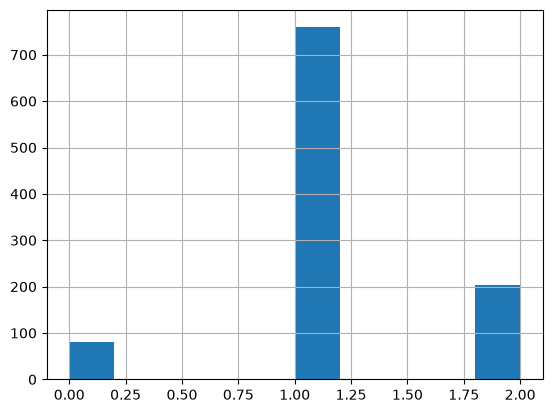

In [9]:
df["G3"].hist()

##

---

## Parte I: Analisi (Punti 10)

### Domanda 01 (Punti 1)

Quante sono le istanze contenute nel dataset? Il dataset è bilanciato rispetto alle scuole e ai generi degli studenti analizzati?

In [10]:
df.shape[0]

1044

> Il dataset contiene 1044 istanze.

In [11]:
df["school"].value_counts()

school
GP    772
MS    272
Name: count, dtype: int64

In [12]:
df["sex"].value_counts()

sex
F    591
M    453
Name: count, dtype: int64

In [13]:
df[["school", "sex"]].value_counts().unstack()

sex,F,M
school,,
GP,420,352
MS,171,101


> Il dataset risulta abbastanza bilanciato rispetto al genere degli studenti, ma sbilanciato rispetto alla scuola. Considerando entrambi gli attributi, possiamo notare come questo sbilanciamento si rifletta in un maggior numero di studentesse della scuola GP.

---

### Domanda 02 (Punti 2)

Creare un nuovo attributo "GRate" che misuri per ogni studente la differenza tra la valutazione ricevuta nel primo e nel secondo periodo. Realizzare un grafico che rappresenti per ogni età questa differenza.

<Axes: xlabel='age'>

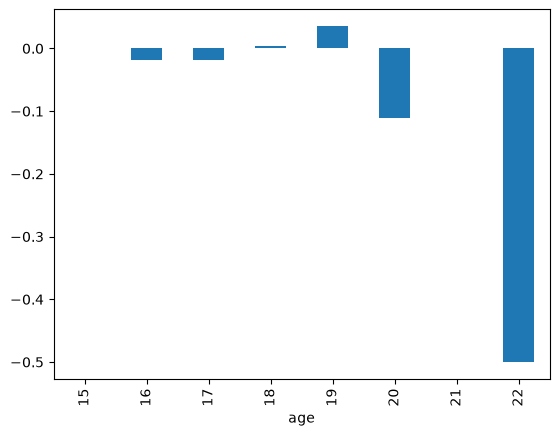

In [14]:
df["GRate"] = df["G1"] - df["G2"]
df.groupby("age")["GRate"].mean().plot(kind="bar")

---

### Domanda 03 (Punti 2)

Sono mediamente più bravi (attributo G3) i ragazzi o le ragazze? Esistono delle variazioni rilevanti nelle due scuole considerate?

In [15]:
df.groupby("sex")["G3"].mean()

sex
F    1.123519
M    1.110375
Name: G3, dtype: float64

> Mediamente, le ragazze sono leggermente più brave rispetto ai ragazzi.

In [16]:
df.groupby(["sex", "school"])["G3"].mean().unstack()

school,GP,MS
sex,,
F,1.128571,1.111111
M,1.153409,0.960396


> Si, in entrambe le scuole la differenza media tra ragazze e ragazzi è minima, ma nella scuola GP i ragazzi hanno una media leggermente più alta delle ragazze, mentre nella scuola MS risulta il contrario, mediamente sono più brave le ragazze rispetto i ragazzi.

---

### Domanda 04 (Punti 2)

Tra i genitori degli studenti considerati, il livello di "educazione" maschile e femminile varia? Sono generalmente più scolarizzati i padri o le madri? Visualizzare poi un grafico che rappresenti il concetto.

In [17]:
df[["Fedu", "Medu"]].value_counts().unstack()

Medu,4,1,3,2,0
Fedu,,,,,
4,165.0,3.0,41.0,15.0,NaN
1,9.0,129.0,35.0,80.0,3.0
2,46.0,51.0,70.0,152.0,5.0
3,84.0,13.0,92.0,42.0,NaN
0,2.0,6.0,NaN,NaN,1.0


<Axes: xlabel='(Fedu, Medu)', ylabel='Counts'>

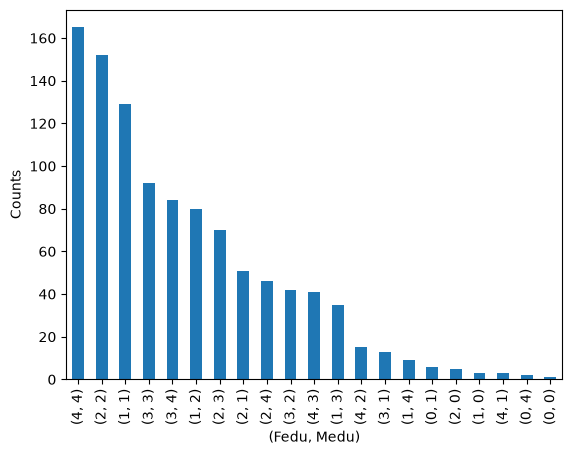

In [18]:
df[["Fedu", "Medu"]].value_counts().plot(kind="bar", ylabel="Counts", xlabel="(Fedu, Medu)")

> La maggior parte dei genitori degli studenti analizzati hanno lo stesso grado di istruzione, a prescindere dal grado di esso. Per i restanti si dividono equamente tra padre con educazione più alta e madre con educazione più alta.

### Domanda 05 (Punti 3)

Indicare cosa visualizza l’istruzione `ds["G3"].groupby([ds["G3"],ds["address"]] ).count().plot()`. Si tratta di una operazione significativa?

In [19]:
df["G3"].groupby([df["G3"], df["address"]]).count()

G3  address
0   R           27
    U           54
1   R          217
    U          542
2   R           41
    U          163
Name: G3, dtype: int64

<Axes: xlabel='G3,address'>

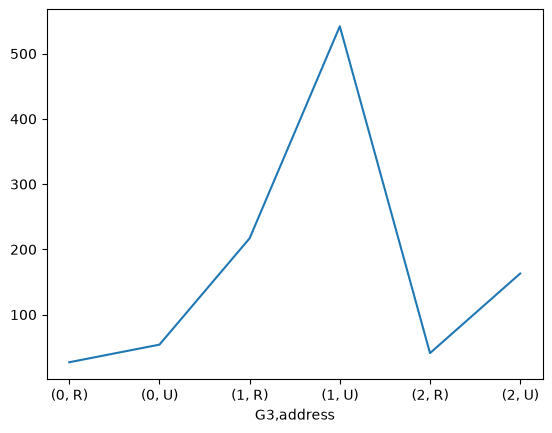

In [20]:
df["G3"].groupby([df["G3"], df["address"]]).count().plot()

> Indica un raggruppamento per voto G3 e zona di residenza. Vengono contati quanti studenti risiedono in zona rurale e urbana per ogni voto G3 ottenuto. Potrebbe essere rilevante se si vuole sapere le zone di provenienza in base al voto G3 ottenuto.

##

---

## Parte II: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 1)

Scikit-learn utilizza un array numpy per effettuare le proprie predizioni. Gli elementi dell’array numpy devono essere di tipo numerico. Creare un dataset chiamato "numeric" che contiene solo le features numeriche.

Creare poi un nuovo dataset "reduced" dall’originale con le colonne G1 e G2 e un dataset "lessReduced" togliendo da numeric unicamente le colonne G1 e G2.

In [21]:
numeric = df.select_dtypes(include=[np.number]).copy()
numeric.dtypes

age           int64
famsize       int64
Medu          int64
Fedu          int64
traveltime    int64
studytime     int64
failures      int64
schoolsup     int64
famsup        int64
paid          int64
nursery       int64
higher        int64
internet      int64
romantic      int64
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
GRate         int64
dtype: object

In [22]:
reduced = df[["G1", "G2", "G3"]].copy()
reduced.columns

Index(['G1', 'G2', 'G3'], dtype='str')

In [23]:
less_reduced = numeric.drop(["G1", "G2"], axis=1).copy()
less_reduced.columns

Index(['age', 'famsize', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'nursery', 'higher', 'internet',
       'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
       'absences', 'G3', 'GRate'],
      dtype='str')

---

### Domanda 02 (Punti 3)

Si vuole predire G3 sulla base degli altri attributi presenti nel dataset. Dividere i dataset numeric, lessReduced e reduced in modo che 2/3 degli elementi siano contenuti in un nuovo dataset "train" e 1/3 nel dataset "test".

Valutare l’accuracy ottenuta con il modello LogisticRegression su tutti i dataset. Il valore di accuratezza ottenuto è pari a? La confusion matrix presenta qualche valore significativo.

In [24]:
X_numeric, y_numeric = numeric.drop("G3", axis=1), numeric["G3"]
X_reduced, y_reduced = reduced.drop("G3", axis=1), reduced["G3"]
X_less_reduced, y_less_reduced = less_reduced.drop("G3", axis=1), less_reduced["G3"]

In [25]:
X_numeric_train, X_numeric_test, y_numeric_train, y_numeric_test = train_test_split(X_numeric, y_numeric, test_size=1/3, stratify=y_numeric, random_state=0)
X_reduced_train, X_reduced_test, y_reduced_train, y_reduced_test = train_test_split(X_reduced, y_reduced, test_size=1/3, stratify=y_reduced, random_state=0)
X_less_reduced_train, X_less_reduced_test, y_less_reduced_train, y_less_reduced_test = train_test_split(X_less_reduced, y_less_reduced, test_size=1/3, stratify=y_less_reduced, random_state=0)

In [26]:
datasets = {
    "Numeric": {
        "train": (X_numeric_train, y_numeric_train),
        "test": (X_numeric_test, y_numeric_test),
    },
    "Reduced": {
        "train": (X_reduced_train, y_reduced_train),
        "test": (X_reduced_test, y_reduced_test),
    },
    "LessReduced": {
        "train": (X_less_reduced_train, y_less_reduced_train),
        "test": (X_less_reduced_test, y_less_reduced_test),
    },
}

logistic_regression = LogisticRegression(max_iter=1000, random_state=0)

for name, data in datasets.items():
    logistic_regression.fit(*data["train"])
    y_pred_train = logistic_regression.predict(data["train"][0])
    y_pred_test = logistic_regression.predict(data["test"][0])
    print(name)
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(data["train"][1], y_pred_train))
    print("    F1:", f1_score(data["train"][1], y_pred_train, average="macro"))
    print(confusion_matrix(data["train"][1], y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(data["test"][1], y_pred_test))
    print("    F1:", f1_score(data["test"][1], y_pred_test, average="macro"))
    print(confusion_matrix(data["test"][1], y_pred_test))
    print("=" * 30)
    print()

Numeric
TRAIN
    Accuracy: 0.9295977011494253
    F1: 0.8598939437982667
[[ 33  21   0]
 [  5 499   2]
 [  0  21 115]]
------------------------------
TEST
    Accuracy: 0.9109195402298851
    F1: 0.823201945559739
[[ 15  12   0]
 [  4 249   0]
 [  0  15  53]]

Reduced
TRAIN
    Accuracy: 0.9252873563218391
    F1: 0.8595966832375707
[[ 35  19   0]
 [  6 498   2]
 [  0  25 111]]
------------------------------
TEST
    Accuracy: 0.9080459770114943
    F1: 0.8194877404065263
[[ 15  12   0]
 [  4 249   0]
 [  0  16  52]]

LessReduced
TRAIN
    Accuracy: 0.7701149425287356
    F1: 0.5229802880311399
[[ 10  43   1]
 [  2 486  18]
 [  1  95  40]]
------------------------------
TEST
    Accuracy: 0.7471264367816092
    F1: 0.4600718728208466
[[  2  25   0]
 [  2 237  14]
 [  0  47  21]]



> Dai risultati delle accuracy possiamo notare che il modello `LogisticRegression` lavora abbastanza bene con i dataset `numeric` e `reduced`, con accuracy del 90%, mentre con il dataset `less_reduced` non lavora troppo bene, con accuracy del 77%.
>
> Sui primi dataset possiamo notare dalla confusion matrix che vengono predette erroneamente le classi 0 e 2, le quali il modello le predice come classe 1.

---

### Domanda 03 (Punti 2)

Che valore di accuratezza si ottiene con un 10 Fold cross validation e il modello basato su Decision Tree? E’ più affidabile la valutazione fatta con la cross validation o quella fatta con una suddivisione arbitraria del dataset in due parti, training set e test set? Per quale motivo?

In [27]:
datasets = {
    "Numeric": (X_numeric, y_numeric),
    "Reduced": (X_reduced, y_reduced),
    "LessReduced": (X_less_reduced, y_less_reduced),
}

decision_tree = DecisionTreeClassifier(random_state=0)

for name, data in datasets.items():
    scores = cross_val_score(decision_tree, data[0], data[1], cv=10)
    print(name)
    print("=" * 30)
    print("    Score mean:", scores.mean())
    print("    Scores:", scores)
    print("=" * 30)
    print()

Numeric
    Score mean: 0.838974358974359
    Scores: [0.87619048 0.8952381  0.85714286 0.83809524 0.81730769 0.86538462
 0.875      0.76923077 0.77884615 0.81730769]

Reduced
    Score mean: 0.908937728937729
    Scores: [0.92380952 0.96190476 0.8952381  0.92380952 0.89423077 0.89423077
 0.92307692 0.85576923 0.90384615 0.91346154]

LessReduced
    Score mean: 0.6780128205128204
    Scores: [0.67619048 0.79047619 0.67619048 0.72380952 0.64423077 0.66346154
 0.68269231 0.60576923 0.68269231 0.63461538]



> Le accuratezze con il modello `DecisionTree` risultano leggermente meno alte rispetto al precedente punto, ad esclusione del dataset `reduced` che presenta performance molto simili.
>
> Una valutazione effettuata attraverso k-fold risulta essere preferibile in casi in cui il dataset non fosse molto grande, inoltre evita di lasciare correlazioni esplitice nei dati come nella suddivisione train e test. Infatti, con la k-fold possiamo avere tanti differenti combinazioni di train e test, e di conseguenza un insieme più randomico di dati al suo interno, rendendolo più accurato.

---

### Domanda 04 (Punti 4)

Considerare il dataset numeric. Considerare l’intervallo di valori assunto dall’attributo age e dividerlo in tre parti. Associare a ogni istanza il valore 0,1,2 a seconda del fatto che l’età sia nel primo, nel secondo o nel terzo intervallo. Eliminare l’attributo age originale, non discretizzato e calcolare l’accuratezza con il metodo 10 cross fold validation.

Trasformare la feature discretizzata in 3 feature booleane, una per ogni valore discretizzato. Il valore assegnato sarà 1 nella colonna che rappresenta il valore in esame. 0 nelle altre colonne. Calcolare l’accuratezza con il metodo 10 cross fold validation.

In [28]:
numeric["age"] = pd.cut(numeric["age"], bins=3, labels=[0, 1, 2])

scores = cross_val_score(decision_tree, X_numeric, y_numeric, cv=10)
print("=" * 30)
print("    Score mean:", scores.mean())
print("    Scores:", scores)
print("=" * 30)
print()

    Score mean: 0.838974358974359
    Scores: [0.87619048 0.8952381  0.85714286 0.83809524 0.81730769 0.86538462
 0.875      0.76923077 0.77884615 0.81730769]



> L'accuratezza del modello `DecisionTree` con il dataset `numeric` risulta essere in linea con l'accuratezza sempre sul dataset `numeric` vista al punto precedente.

In [29]:
pd.get_dummies(numeric, columns=["age"], dtype=int)

scores = cross_val_score(decision_tree, X_numeric, y_numeric, cv=10)
print("=" * 30)
print("    Score mean:", scores.mean())
print("    Scores:", scores)
print("=" * 30)
print()

    Score mean: 0.838974358974359
    Scores: [0.87619048 0.8952381  0.85714286 0.83809524 0.81730769 0.86538462
 0.875      0.76923077 0.77884615 0.81730769]



> Come la precedente trasformazione, anche in aggiunta di quest'ultima, l'accuratezza del modello sul dataset `numeric` risulta essere pressoché la stessa.

---

### Domanda 05 (Punti 4)

Aggiungere al dataset "numeric" gli attributi Mjob e Fjob il cui valore categorico deve essere mappato utilizzando una formula di conversione a scelta. Confrontare il risultato ottenuto con quelli ottenuti in precedenza.

In [30]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
numeric["Mjob"] = encoder.fit_transform(df[["Mjob"]])
numeric["Fjob"] = encoder.fit_transform(df[["Fjob"]])

scores = cross_val_score(decision_tree, X_numeric, y_numeric, cv=10)
print("=" * 30)
print("    Score mean:", scores.mean())
print("    Scores:", scores)
print("=" * 30)
print()

    Score mean: 0.838974358974359
    Scores: [0.87619048 0.8952381  0.85714286 0.83809524 0.81730769 0.86538462
 0.875      0.76923077 0.77884615 0.81730769]



> Seppur l'aggiunta di nuove feature al dataset `numeric`, l'accuratezza del modello `DecisionTree` rimane la stessa di quelle viste negli ultimi punti in esame.

---

### Domanda 06 (Punti 3)

Partendo dal dataset originale, costruire due dataset contenenti solo le feature numeriche. Uno che rappresenti la scuola GP e l’altro la scuola MS. Costruire due modelli di predizione utilizzando il decision tree. Uno per gli studenti GP e l’altro per gli studenti MS. Allenare entrambi i modelli utilizzando 2/3 delle rispettive istanze come training. Fondere i test in un unico file. Verificare l’accuratezza ottenuta dal test in entrambi i modelli. Quale funziona meglio?

In [31]:
df = pd.read_csv("dataset.csv", sep=";")
school_gp = df[df["school"] == "GP"].select_dtypes(include=[np.number])
school_ms = df[df["school"] == "MS"].select_dtypes(include=[np.number])

In [32]:
X_school_gp, y_school_gp = school_gp.drop("G3", axis=1), school_gp["G3"]
X_school_ms, y_school_ms = school_ms.drop("G3", axis=1), school_ms["G3"]
X_school_gp_train, X_school_gp_test, y_school_gp_train, y_school_gp_test = train_test_split(X_school_gp, y_school_gp, test_size=1/3, stratify=y_school_gp, random_state=0)
X_school_ms_train, X_school_ms_test, y_school_ms_train, y_school_ms_test = train_test_split(X_school_ms, y_school_ms, test_size=1/3, stratify=y_school_ms, random_state=0)

In [33]:
decision_tree.fit(X_school_gp_train, y_school_gp_train)
y_pred_train = decision_tree.predict(X_school_gp_train)
y_pred_test = decision_tree.predict(X_school_gp_test)
print("GP")
print("=" * 30)
print("TRAIN")
print("    Accuracy:", accuracy_score(y_school_gp_train, y_pred_train))
print("    F1:", f1_score(y_school_gp_train, y_pred_train, average="macro"))
print(confusion_matrix(y_school_gp_train, y_pred_train))
print("-" * 30)
print("TEST")
print("    Accuracy:", accuracy_score(y_school_gp_test, y_pred_test))
print("    F1:", f1_score(y_school_gp_test, y_pred_test, average="macro"))
print(confusion_matrix(y_school_gp_test, y_pred_test))
print("=" * 30)

GP
TRAIN
    Accuracy: 0.9961089494163424
    F1: 0.9933565441756059
[[ 39   0   0]
 [  1 363   0]
 [  0   1 110]]
------------------------------
TEST
    Accuracy: 0.8410852713178295
    F1: 0.7439660382466314
[[ 10  10   0]
 [  6 160  16]
 [  0   9  47]]


In [34]:
decision_tree.fit(X_school_ms_train, y_school_ms_train)
y_pred_train = decision_tree.predict(X_school_ms_train)
y_pred_test = decision_tree.predict(X_school_ms_test)
print("MS")
print("=" * 30)
print("TRAIN")
print("    Accuracy:", accuracy_score(y_school_ms_train, y_pred_train))
print("    F1:", f1_score(y_school_ms_train, y_pred_train, average="macro"))
print(confusion_matrix(y_school_ms_train, y_pred_train))
print("-" * 30)
print("TEST")
print("    Accuracy:", accuracy_score(y_school_ms_test, y_pred_test))
print("    F1:", f1_score(y_school_ms_test, y_pred_test, average="macro"))
print(confusion_matrix(y_school_ms_test, y_pred_test))
print("=" * 30)

MS
TRAIN
    Accuracy: 1.0
    F1: 1.0
[[ 15   0   0]
 [  0 142   0]
 [  0   0  24]]
------------------------------
TEST
    Accuracy: 0.8901098901098901
    F1: 0.7957926587658947
[[ 5  2  0]
 [ 5 66  0]
 [ 0  3 10]]


> Il modello `DecisionTree` sembra mostrare valori di accuratezza più alti utilizzando il dataset `MS`, mostrando valori di 89% contro gli 84% del dataset `GP`.

---

### Domanda 07 (Punti 3)

Utilizzare un algoritmo di regressione da applicarsi al dataset del punto 1 per predire "G3". Arrotondare i valori ottenuti all’intero. Confrontare i risultati ottenuti con quelli ottenuti in precedenza.

In [35]:
X, y = numeric.drop("G3", axis=1), numeric["G3"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, stratify=y, random_state=0)

In [36]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
y_pred_train = np.round(linear_regression.predict(X_train)).astype(int)
y_pred_test = np.round(linear_regression.predict(X_test)).astype(int)
print("TRAIN")
print("    Accuracy:", accuracy_score(y_train, y_pred_train))
print("    F1:", f1_score(y_train, y_pred_train, average="macro"))
print(confusion_matrix(y_train, y_pred_train))
print("-" * 30)
print("TEST")
print("    Accuracy:", accuracy_score(y_test, y_pred_test))
print("    F1:", f1_score(y_test, y_pred_test, average="macro"))
print(confusion_matrix(y_test, y_pred_test))

TRAIN
    Accuracy: 0.9252873563218391
    F1: 0.8595966832375707
[[ 35  19   0]
 [  6 498   2]
 [  0  25 111]]
------------------------------
TEST
    Accuracy: 0.9080459770114943
    F1: 0.8194877404065263
[[ 15  12   0]
 [  4 249   0]
 [  0  16  52]]


> Il modello `LinearRegression` mostra valori di accuratezza abbastanza alti rispetto ai punti precedenti, toccando il 90%. Questo valore risulta paragonabile a quelli ottenuti al punto 2 con modello `LogisticRegression` e dataset `numeric`, 91%, e dataset `reduced`, 90%.